## we will answer two questions:
- the players that have a palce of birith that is different than the mationality teams they prsented 
- the players that have multiple citizenships and present one national team of them
 

### players that have a place of birith differnet than thier national team 
- we will ignore the players that thier place of birsith is none


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
DataSet_DIR = '../PreProcessdData'
player_profile_df = pd.read_csv(f'{DataSet_DIR}/player_profiles/player_profiles.csv')
club_details_df = pd.read_csv(f'{DataSet_DIR}/team_details/team_details.csv')
national_performances_df = pd.read_csv(f'{DataSet_DIR}/player_national_performances/player_national_performances.csv')

national_performances_teams_df = national_performances_df.merge(
    club_details_df[['club_id', 'club_name']],
    left_on='team_id',
    right_on='club_id',
    how='inner'
)

print(national_performances_teams_df.head())


> unfortuantly the details about the national teams is not in the dataset so we can't define what is the team they have prsented and couldn't answer the quesiton 

### players that have multiple citizenship and chosen only one  
- we still will not be able to decide which team they choose 


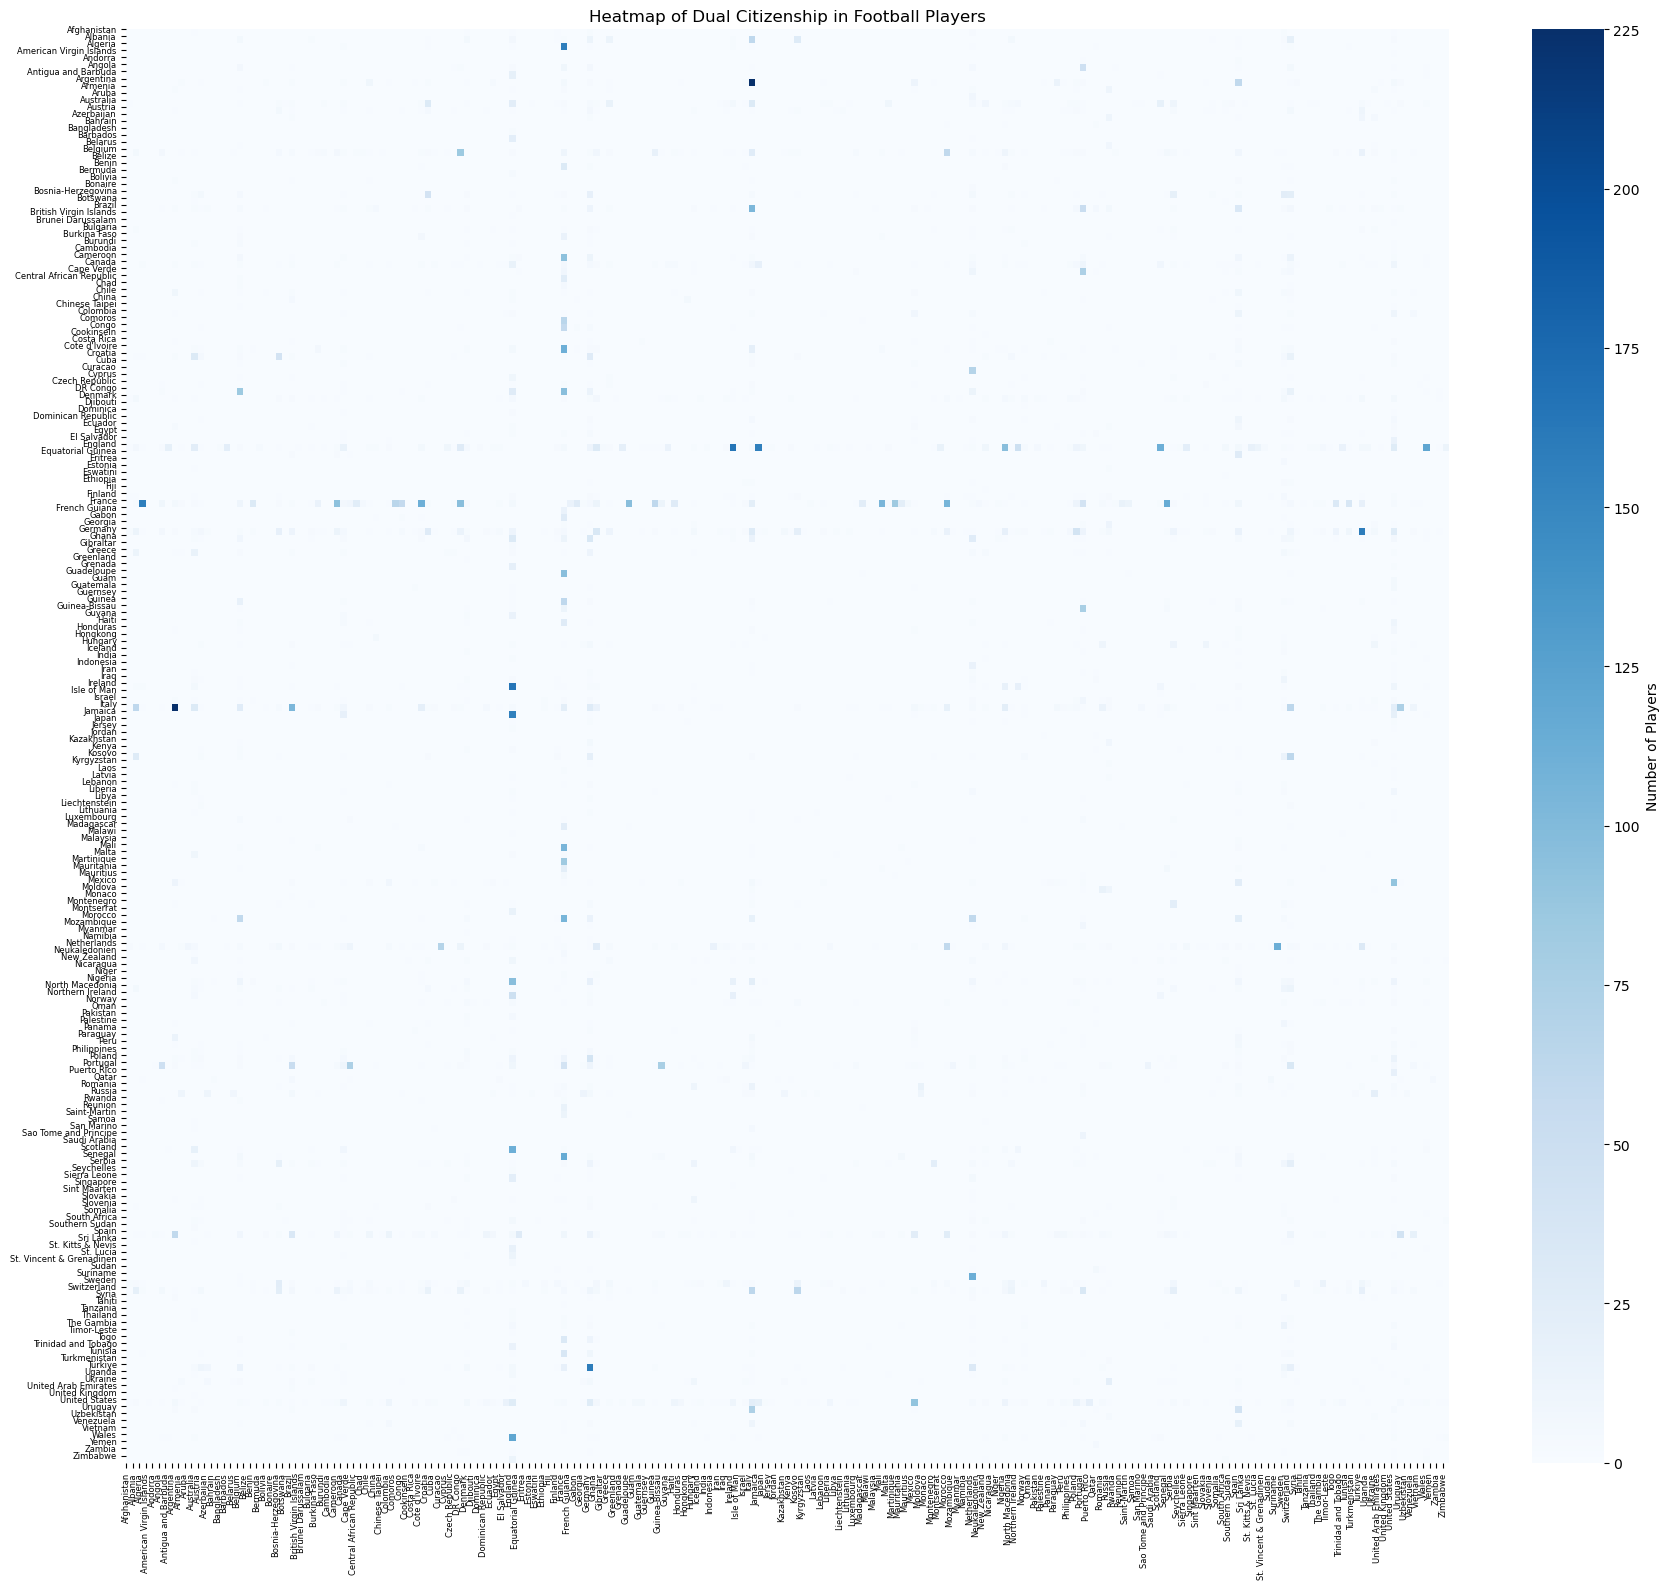

In [10]:
from collections import Counter
# let's filter out players who have no national team appearances
# delete performances with 0 matches
player_ids = national_performances_df[national_performances_df['matches'] > 0]['player_id'].unique()

players = player_profile_df[player_profile_df['player_id'].isin(player_ids)]
players = players[['player_id', 'player_slug', 'citizenship']]
countries = player_profile_df[player_profile_df['country_of_birth'].notnull()]['country_of_birth'].unique()

# Clean & split
players['citizenship_list'] = players['citizenship'].str.split('  ').apply(
    lambda x: list(set(c.strip() for c in x))  # remove duplicates per player
)


# let's make a heatmap of countries and each other which will show how many players have both citizenships

from itertools import combinations



# Count pairs
pair_counts = Counter()

for c_list in players['citizenship_list']:
    if len(c_list) < 2:
        continue
    for c1, c2 in combinations(sorted(c_list), 2):
        pair_counts[(c1, c2)] += 1

# Build matrix
all_countries = sorted(set(c for pair in pair_counts for c in pair))

heatmap_data = pd.DataFrame(0, index=all_countries, columns=all_countries)

for (c1, c2), count in pair_counts.items():
    heatmap_data.loc[c1, c2] = count
    heatmap_data.loc[c2, c1] = count


# Plotting
plt.figure(figsize=(18, 16))  # bigger figure = more space

ax = sns.heatmap(
    heatmap_data,
    cmap='Blues',
    cbar_kws={'label': 'Number of Players'}
)

# Force all labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns, rotation=90, fontsize=6)
ax.set_yticklabels(heatmap_data.index, rotation=0, fontsize=6)

plt.title('Heatmap of Dual Citizenship in Football Players')
plt.tight_layout()
plt.show()

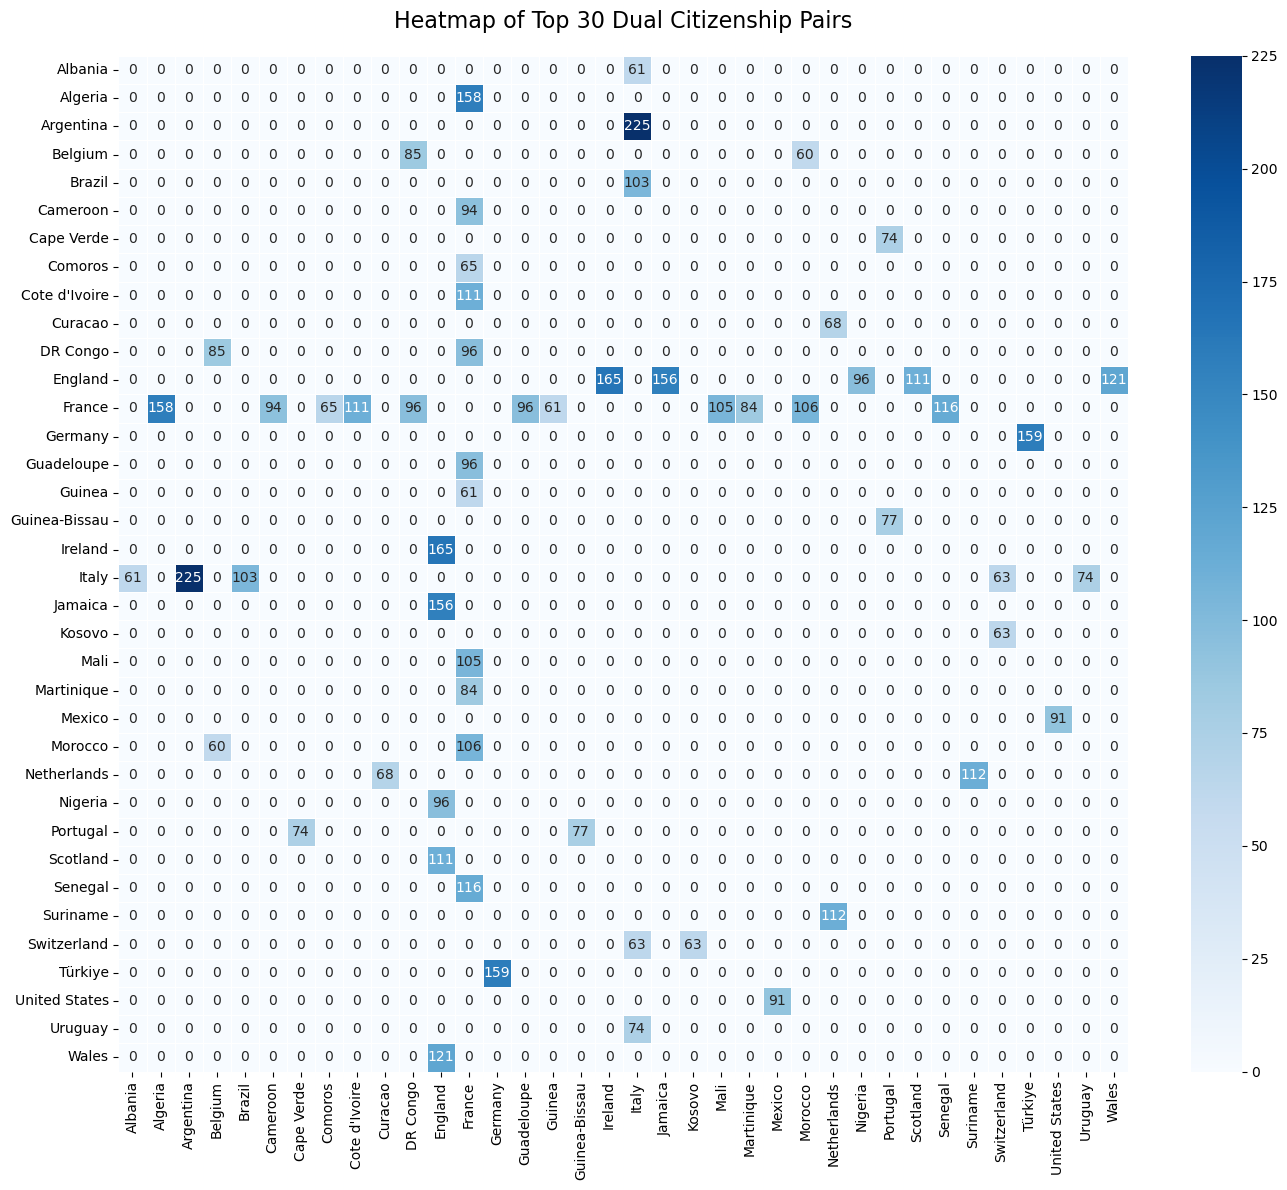

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get top 30 pairs
top_30_pairs = pair_counts.most_common(30)

# 2. Extract unique countries
top_countries = sorted({
    c for (c1, c2), _ in top_30_pairs for c in (c1, c2)
})

# 3. Create a small matrix ONLY for these countries
top_heatmap_data = pd.DataFrame(
    0, index=top_countries, columns=top_countries, dtype=int
)

# 4. Fill ONLY using top pairs (no full matrix needed)
for (c1, c2), count in top_30_pairs:
    top_heatmap_data.loc[c1, c2] = count
    top_heatmap_data.loc[c2, c1] = count

# 5. Plot
plt.figure(figsize=(14, 12))
sns.heatmap(top_heatmap_data, annot=True, fmt='d', cmap='Blues', linewidths=0.5)

plt.title('Heatmap of Top 30 Dual Citizenship Pairs', fontsize=16, pad=20)
plt.tight_layout()
plt.show()